# 🛍️ Customer Segmentation using K-Means Clustering
### SkillCraft Technology Internship — Task 02

**Objective:** Group customers of a retail store based on their purchase history using the K-Means clustering algorithm.

**Dataset Source:** [Kaggle — Mall Customer Segmentation](https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python)

**How to get the data:**
1. Go to the Kaggle dataset link above
2. Download `Mall_Customers.csv`
3. Place it in the **same folder** as this notebook

**Key Features Used:**
| Column | Description |
|--------|-------------|
| `Age` | Age of the customer |
| `Annual Income (k$)` | Annual income in thousands of dollars |
| `Spending Score (1-100)` | Score assigned by the mall (1=low spender, 100=high spender) |

---
## 📦 Step 1: Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, silhouette_samples
from mpl_toolkits.mplot3d import Axes3D

import warnings
warnings.filterwarnings('ignore')

# Plot styling
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


---
## 📂 Step 2: Load the Dataset

In [2]:
# Load the Mall Customers dataset
df = pd.read_csv('Mall_Customers.csv')

print(f'Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns')
print('\nColumn Names:', df.columns.tolist())
print('\nFirst 10 rows:')
df.head(10)

Dataset Shape: 200 rows × 5 columns

Column Names: ['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']

First 10 rows:


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
5,6,Female,22,17,76
6,7,Female,35,18,6
7,8,Female,23,18,94
8,9,Male,64,19,3
9,10,Female,30,19,72


---
## 📊 Step 3: Exploratory Data Analysis (EDA)

In [3]:
# Basic info and statistics
print('Dataset Info:')
print(df.info())
print('\nStatistical Summary:')
df.describe().round(2)

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB
None

Statistical Summary:


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.00,200.00,200.00,200.00
mean,100.50,38.85,60.56,50.20
std,57.88,13.97,26.26,25.82
min,1.00,18.00,15.00,1.00
25%,50.75,28.75,41.50,34.75
50%,100.50,36.00,61.50,50.00
75%,150.25,49.00,78.00,73.00
max,200.00,70.00,137.00,99.00


In [4]:
# Check missing values
print('Missing Values:')
print(df.isnull().sum())
print('\n✅ No missing values!')

Missing Values:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

✅ No missing values!


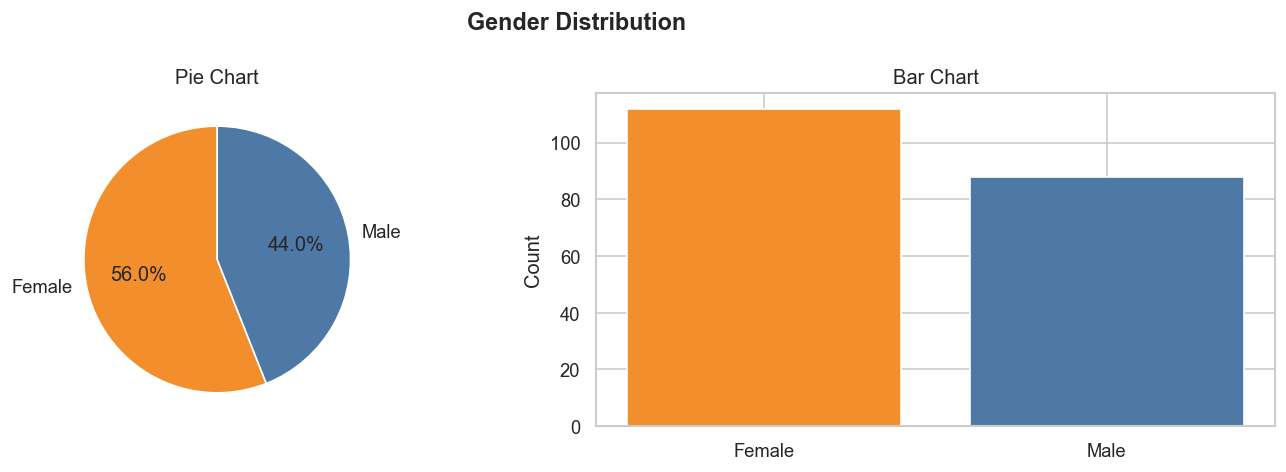

In [6]:
# Gender distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Gender Distribution', fontsize=14, fontweight='bold')

gender_counts = df['Gender'].value_counts()
colors = ['#f28e2b', '#4e79a7']

axes[0].pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90, wedgeprops={'edgecolor':'white'})
axes[0].set_title('Pie Chart')

axes[1].bar(gender_counts.index, gender_counts.values, color=colors, edgecolor='white')
axes[1].set_title('Bar Chart')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

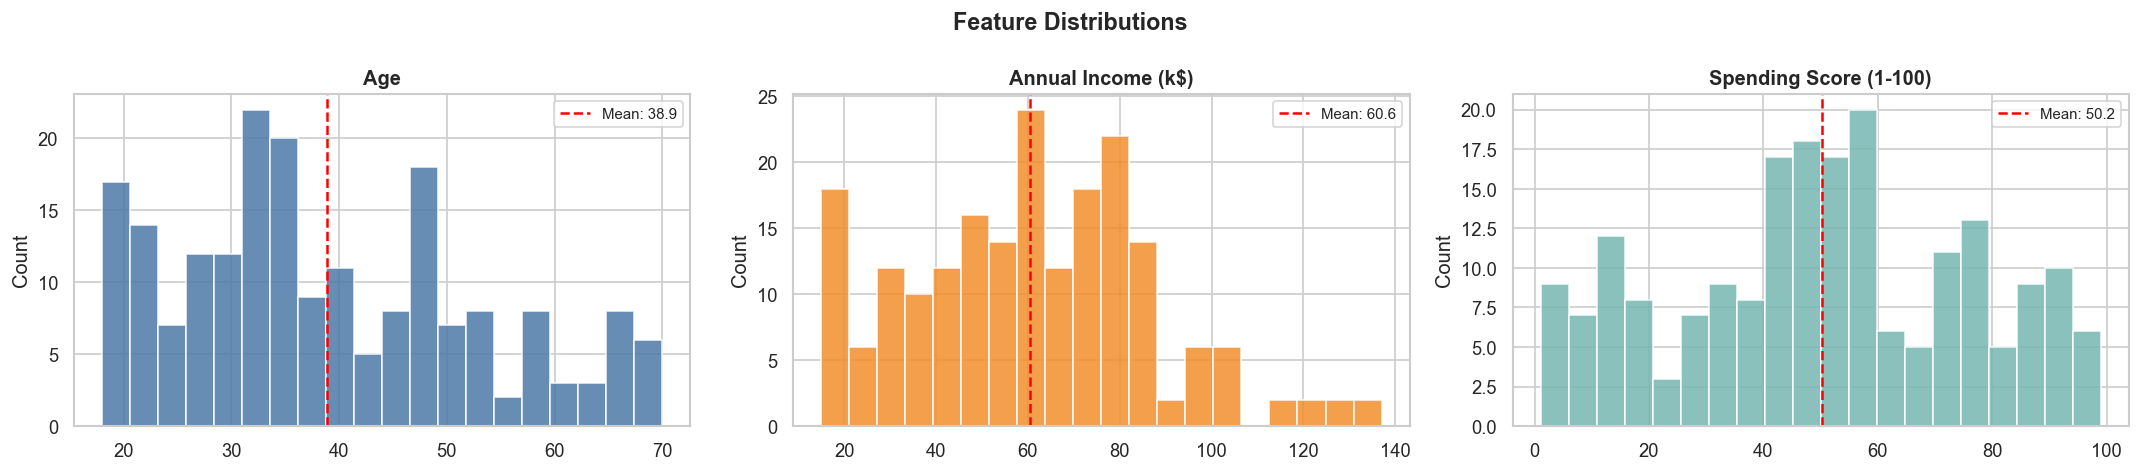

In [7]:
# Feature distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle('Feature Distributions', fontsize=14, fontweight='bold')

features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
colors   = ['#4e79a7', '#f28e2b', '#76b7b2']

for ax, feat, color in zip(axes, features, colors):
    ax.hist(df[feat], bins=20, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(df[feat].mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean: {df[feat].mean():.1f}')
    ax.set_title(feat, fontweight='bold')
    ax.set_ylabel('Count')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

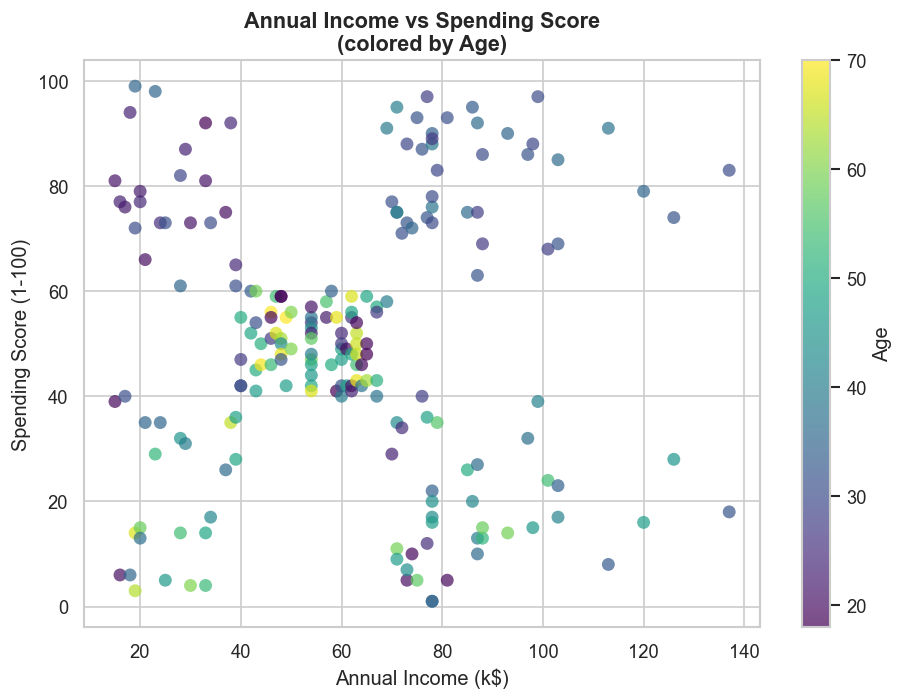

In [8]:
# Scatter plot: Annual Income vs Spending Score (main clustering view)
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    df['Annual Income (k$)'],
    df['Spending Score (1-100)'],
    c=df['Age'], cmap='viridis', alpha=0.7, s=60, edgecolors='none'
)
plt.colorbar(scatter, label='Age')
plt.xlabel('Annual Income (k$)', fontsize=12)
plt.ylabel('Spending Score (1-100)', fontsize=12)
plt.title('Annual Income vs Spending Score\n(colored by Age)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

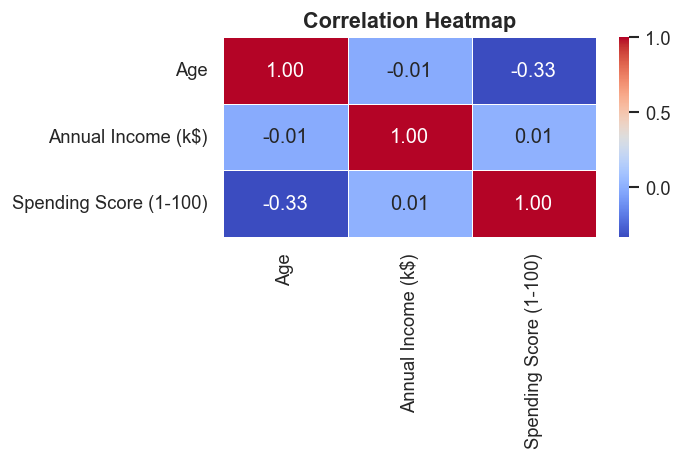

In [9]:
# Correlation heatmap
plt.figure(figsize=(6, 4))
corr = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5, annot_kws={'size': 12})
plt.title('Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## ⚙️ Step 4: Data Preprocessing

In [10]:
# Select features for clustering
# We use Annual Income and Spending Score as the primary features
# (Most commonly used for this dataset — gives clear 5 cluster separation)
X = df[['Annual Income (k$)', 'Spending Score (1-100)']].values

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'Feature matrix shape : {X_scaled.shape}')
print(f'Scaled mean          : {X_scaled.mean(axis=0).round(4)}')
print(f'Scaled std           : {X_scaled.std(axis=0).round(4)}')
print('\n✅ Features scaled using StandardScaler!')

Feature matrix shape : (200, 2)
Scaled mean          : [-0. -0.]
Scaled std           : [1. 1.]

✅ Features scaled using StandardScaler!


---
## 🔍 Step 5: Find Optimal K — Elbow Method

In [11]:
# Calculate WCSS (Within-Cluster Sum of Squares) for k = 1 to 10
wcss = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
    print(f'  k={k:2d}  WCSS={kmeans.inertia_:.4f}')

print('\n✅ WCSS computed for all k values!')

  k= 1  WCSS=400.0000
  k= 2  WCSS=269.6910
  k= 3  WCSS=157.7040
  k= 4  WCSS=108.9213
  k= 5  WCSS=65.5684
  k= 6  WCSS=55.0573
  k= 7  WCSS=44.8648
  k= 8  WCSS=37.2282
  k= 9  WCSS=32.3923
  k=10  WCSS=29.9819

✅ WCSS computed for all k values!


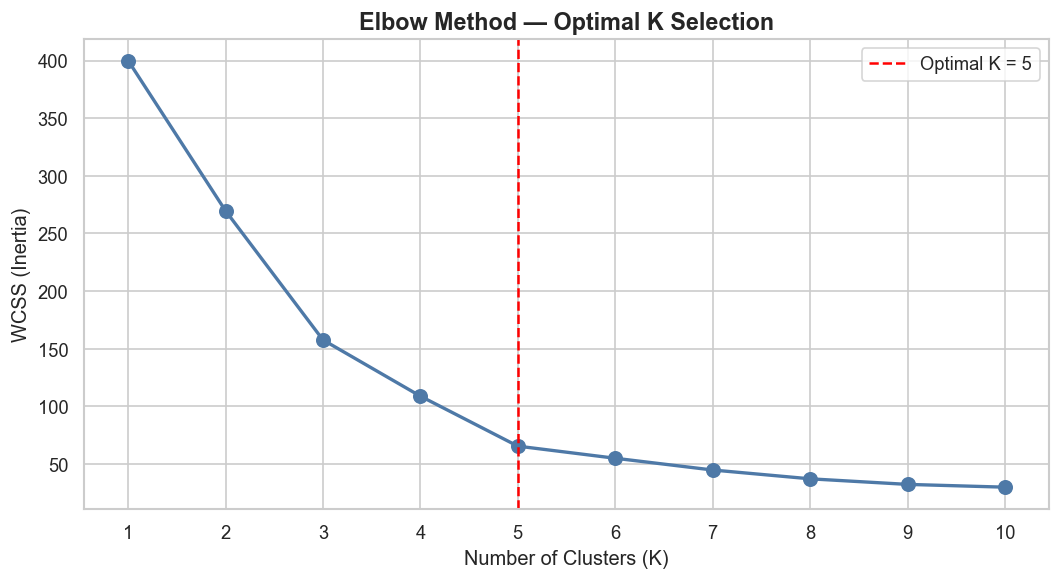

💡 The "elbow" at K=5 suggests 5 is the optimal number of clusters.


In [12]:
# Plot the Elbow Curve
plt.figure(figsize=(9, 5))
plt.plot(k_range, wcss, 'bo-', markersize=8, linewidth=2, color='#4e79a7')
plt.axvline(x=5, color='red', linestyle='--', linewidth=1.5, label='Optimal K = 5')
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('WCSS (Inertia)', fontsize=12)
plt.title('Elbow Method — Optimal K Selection', fontsize=14, fontweight='bold')
plt.xticks(k_range)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print('💡 The "elbow" at K=5 suggests 5 is the optimal number of clusters.')

---
## 📐 Step 6: Validate K — Silhouette Score

In [13]:
# Silhouette Score for k = 2 to 10
sil_scores = []
k_range_sil = range(2, 11)

for k in k_range_sil:
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score  = silhouette_score(X_scaled, labels)
    sil_scores.append(score)
    print(f'  k={k:2d}  Silhouette Score = {score:.4f}')

best_k = k_range_sil[np.argmax(sil_scores)]
print(f'\n🏆 Best K by Silhouette Score: {best_k} (Score = {max(sil_scores):.4f})')

  k= 2  Silhouette Score = 0.3213
  k= 3  Silhouette Score = 0.4666
  k= 4  Silhouette Score = 0.4939
  k= 5  Silhouette Score = 0.5547
  k= 6  Silhouette Score = 0.5399
  k= 7  Silhouette Score = 0.5281
  k= 8  Silhouette Score = 0.4552
  k= 9  Silhouette Score = 0.4571
  k=10  Silhouette Score = 0.4432

🏆 Best K by Silhouette Score: 5 (Score = 0.5547)


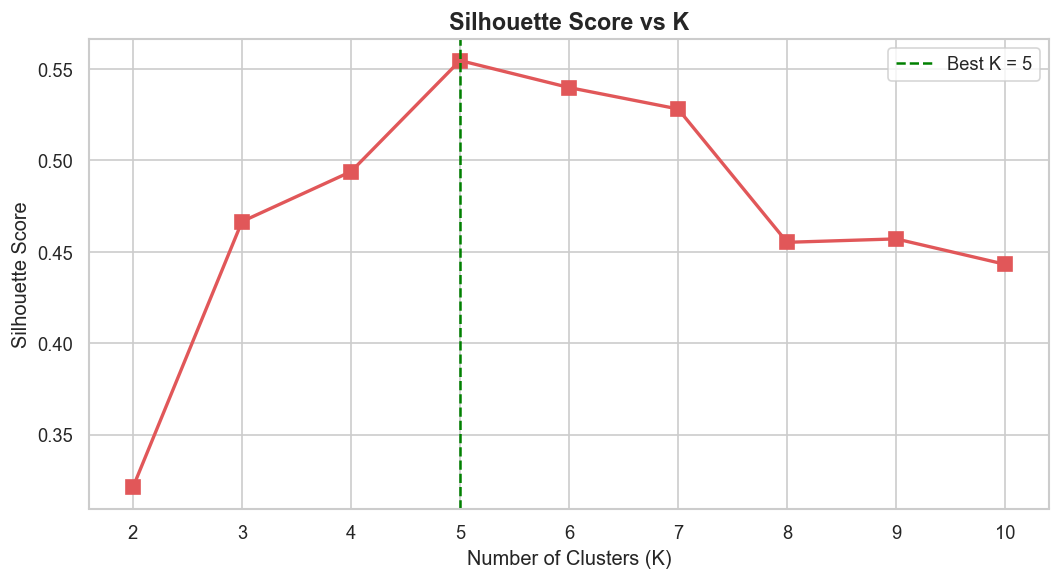

In [14]:
# Plot Silhouette Scores
plt.figure(figsize=(9, 5))
plt.plot(list(k_range_sil), sil_scores, 's-', markersize=8, linewidth=2, color='#e15759')
plt.axvline(x=best_k, color='green', linestyle='--', linewidth=1.5, label=f'Best K = {best_k}')
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.title('Silhouette Score vs K', fontsize=14, fontweight='bold')
plt.xticks(list(k_range_sil))
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

---
## 🤖 Step 7: Train Final K-Means Model (K=5)

In [15]:
# Train K-Means with optimal K=5
OPTIMAL_K = 5

kmeans_final = KMeans(
    n_clusters=OPTIMAL_K,
    init='k-means++',   # Smart centroid initialization
    n_init=10,          # Run 10 times, pick best
    max_iter=300,
    random_state=42
)

df['Cluster'] = kmeans_final.fit_predict(X_scaled)

# Get centroids (inverse transform back to original scale)
centroids_scaled = kmeans_final.cluster_centers_
centroids_orig   = scaler.inverse_transform(centroids_scaled)

print(f'✅ K-Means trained with K={OPTIMAL_K}!')
print(f'\nFinal WCSS (Inertia): {kmeans_final.inertia_:.4f}')
print(f'Silhouette Score    : {silhouette_score(X_scaled, df["Cluster"]):.4f}')
print('\nCluster Centroids (original scale):')
centroid_df = pd.DataFrame(centroids_orig,
                            columns=['Annual Income (k$)', 'Spending Score'],
                            index=[f'Cluster {i}' for i in range(OPTIMAL_K)])
print(centroid_df.round(2))

✅ K-Means trained with K=5!

Final WCSS (Inertia): 65.5684
Silhouette Score    : 0.5547

Cluster Centroids (original scale):
           Annual Income (k$)  Spending Score
Cluster 0               55.30           49.52
Cluster 1               86.54           82.13
Cluster 2               25.73           79.36
Cluster 3               88.20           17.11
Cluster 4               26.30           20.91


---
## 📈 Step 8: Visualize Clusters

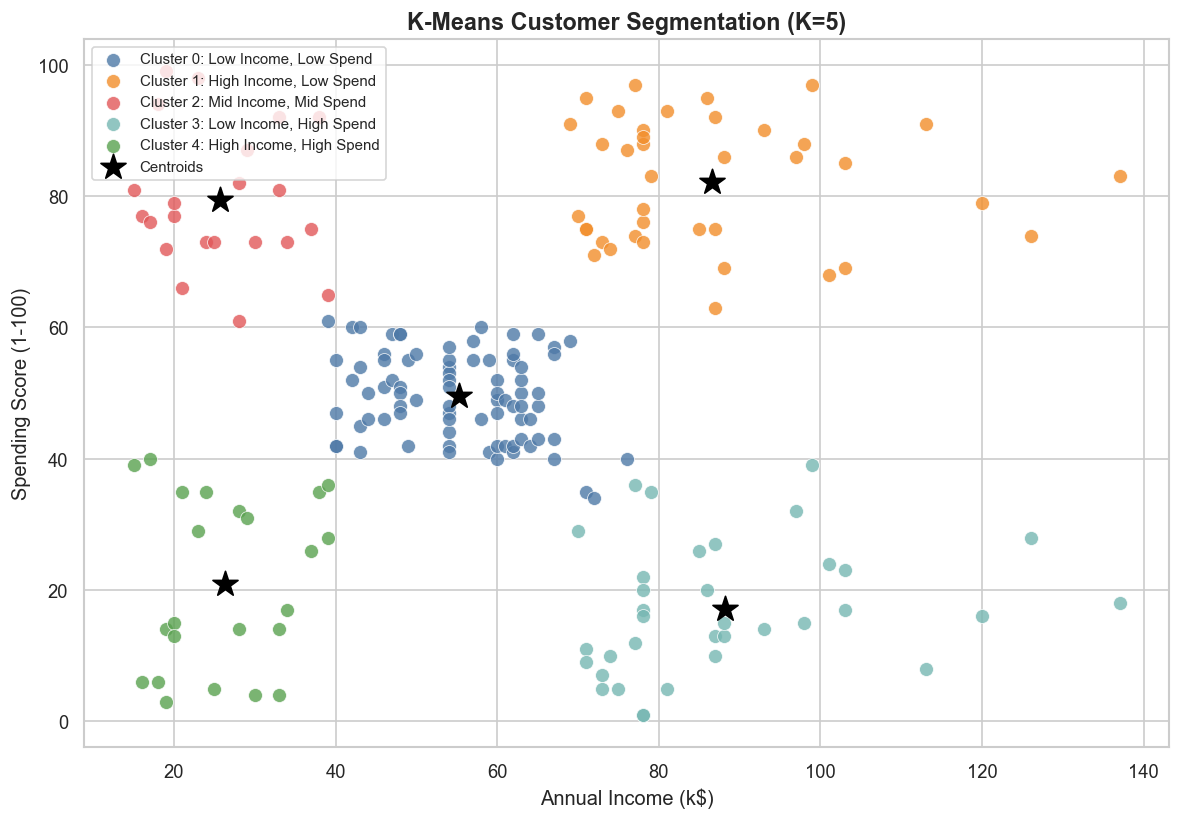

In [16]:
# 2D Cluster Plot — Annual Income vs Spending Score
cluster_colors  = ['#4e79a7', '#f28e2b', '#e15759', '#76b7b2', '#59a14f']
cluster_labels  = [
    'Cluster 0: Low Income, Low Spend',
    'Cluster 1: High Income, Low Spend',
    'Cluster 2: Mid Income, Mid Spend',
    'Cluster 3: Low Income, High Spend',
    'Cluster 4: High Income, High Spend'
]

plt.figure(figsize=(10, 7))

for i in range(OPTIMAL_K):
    mask = df['Cluster'] == i
    plt.scatter(
        df.loc[mask, 'Annual Income (k$)'],
        df.loc[mask, 'Spending Score (1-100)'],
        s=70, color=cluster_colors[i], label=cluster_labels[i],
        alpha=0.8, edgecolors='white', linewidth=0.5
    )

# Plot centroids
plt.scatter(
    centroids_orig[:, 0], centroids_orig[:, 1],
    s=250, c='black', marker='*', zorder=5, label='Centroids'
)

plt.xlabel('Annual Income (k$)', fontsize=12)
plt.ylabel('Spending Score (1-100)', fontsize=12)
plt.title('K-Means Customer Segmentation (K=5)', fontsize=14, fontweight='bold')
plt.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

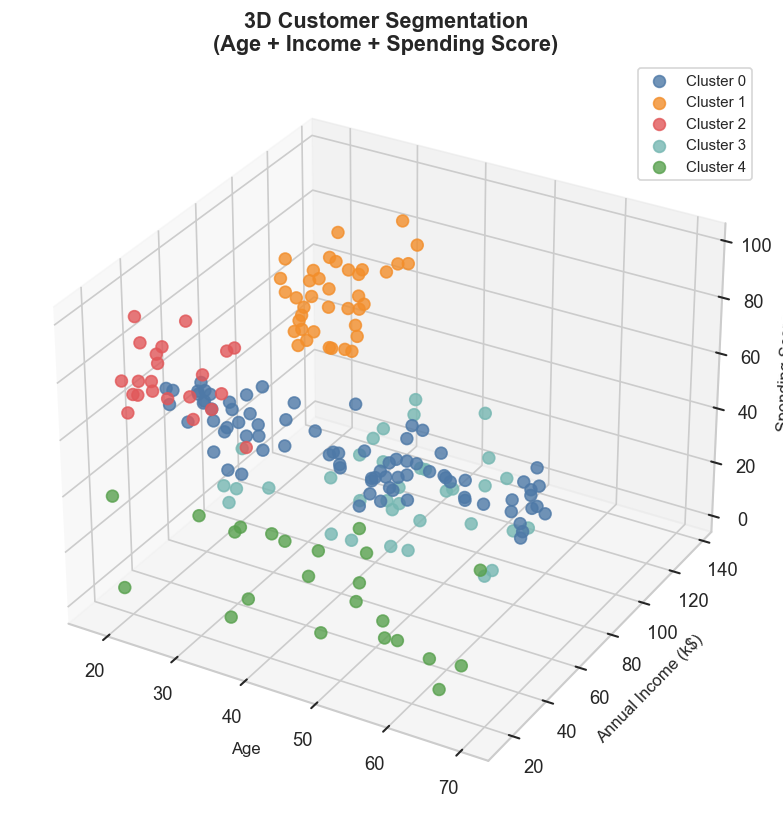

In [17]:
# 3D Cluster Plot — Age + Annual Income + Spending Score
fig = plt.figure(figsize=(11, 7))
ax  = fig.add_subplot(111, projection='3d')

for i in range(OPTIMAL_K):
    mask = df['Cluster'] == i
    ax.scatter(
        df.loc[mask, 'Age'],
        df.loc[mask, 'Annual Income (k$)'],
        df.loc[mask, 'Spending Score (1-100)'],
        s=50, color=cluster_colors[i], label=f'Cluster {i}', alpha=0.8
    )

ax.set_xlabel('Age', fontsize=10)
ax.set_ylabel('Annual Income (k$)', fontsize=10)
ax.set_zlabel('Spending Score', fontsize=10)
ax.set_title('3D Customer Segmentation\n(Age + Income + Spending Score)', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

---
## 📋 Step 9: Cluster Analysis & Profiling

In [18]:
# Cluster summary statistics
profile = df.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].agg(['mean', 'count'])
print('Cluster Profile (mean values):')
print(profile.round(2))

Cluster Profile (mean values):
           Age       Annual Income (k$)       Spending Score (1-100)      
          mean count               mean count                   mean count
Cluster                                                                   
0        42.72    81              55.30    81                  49.52    81
1        32.69    39              86.54    39                  82.13    39
2        25.27    22              25.73    22                  79.36    22
3        41.11    35              88.20    35                  17.11    35
4        45.22    23              26.30    23                  20.91    23


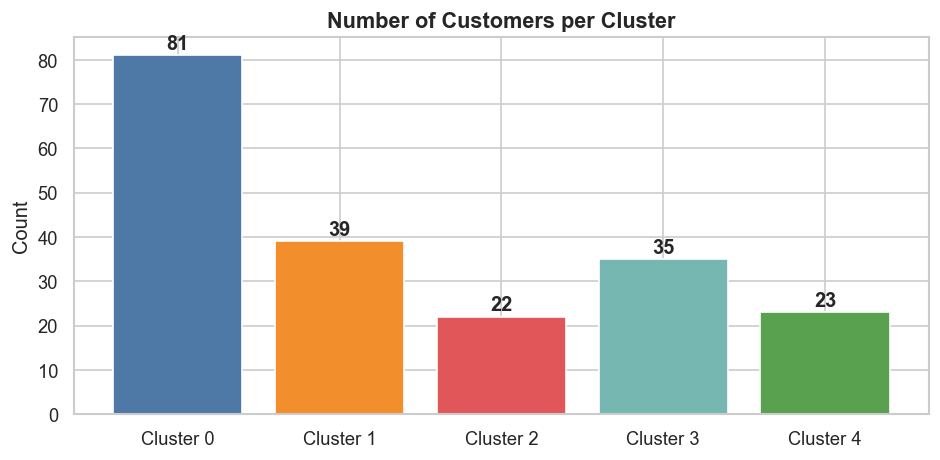

In [19]:
# Cluster sizes
cluster_sizes = df['Cluster'].value_counts().sort_index()

plt.figure(figsize=(8, 4))
bars = plt.bar(
    [f'Cluster {i}' for i in range(OPTIMAL_K)],
    cluster_sizes.values,
    color=cluster_colors, edgecolor='white'
)
for bar, val in zip(bars, cluster_sizes.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             str(val), ha='center', va='bottom', fontweight='bold')
plt.title('Number of Customers per Cluster', fontsize=13, fontweight='bold')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

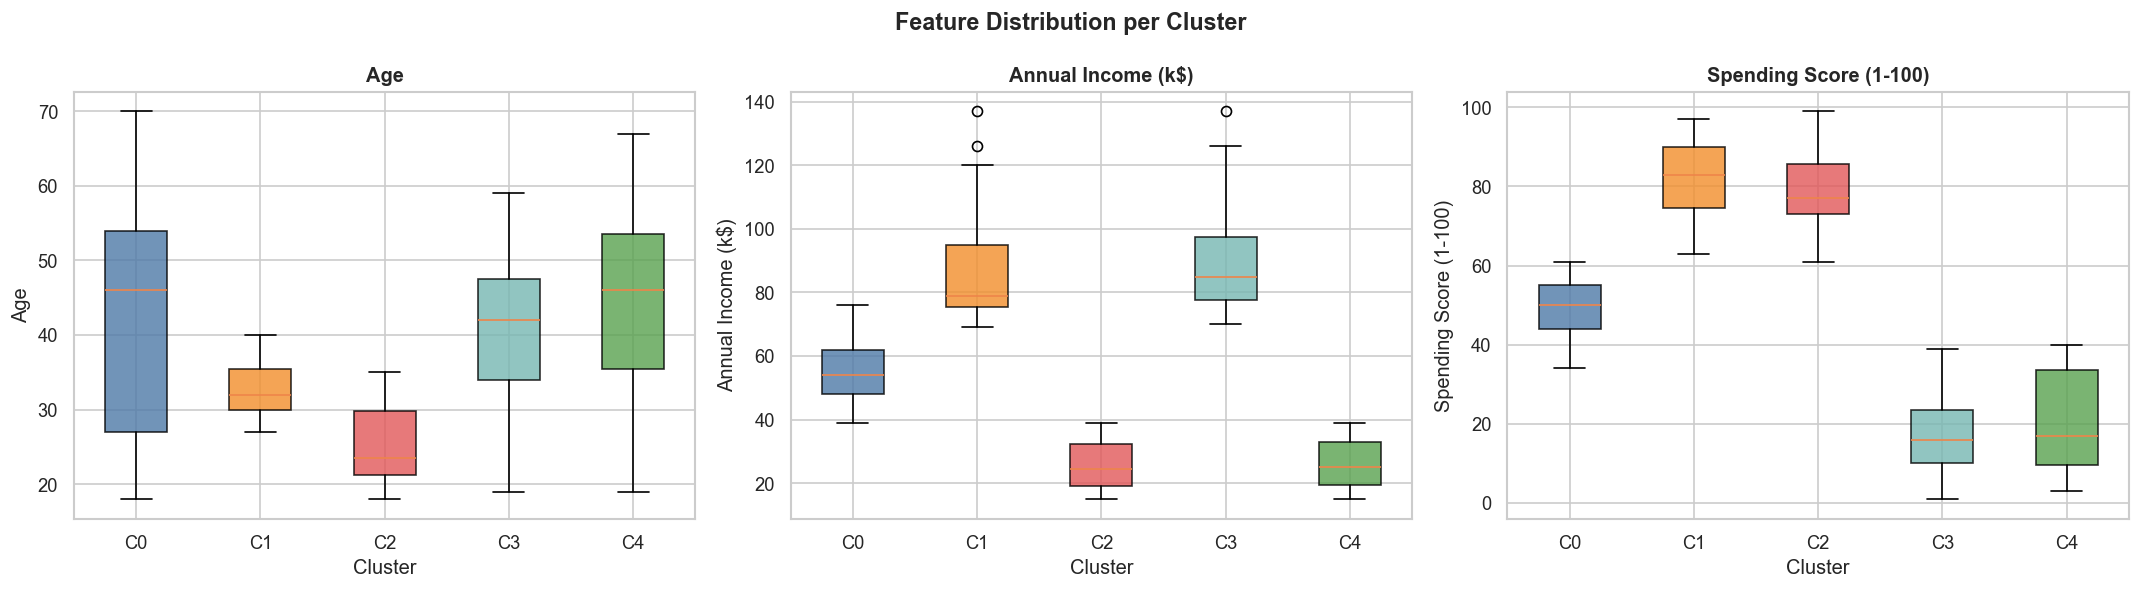

In [20]:
# Box plots per cluster
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Feature Distribution per Cluster', fontsize=14, fontweight='bold')

features_box = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']

for ax, feat in zip(axes, features_box):
    data_by_cluster = [df.loc[df['Cluster'] == i, feat].values for i in range(OPTIMAL_K)]
    bp = ax.boxplot(data_by_cluster, patch_artist=True, notch=False)
    for patch, color in zip(bp['boxes'], cluster_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)
    ax.set_xticklabels([f'C{i}' for i in range(OPTIMAL_K)])
    ax.set_title(feat, fontweight='bold')
    ax.set_xlabel('Cluster')
    ax.set_ylabel(feat)

plt.tight_layout()
plt.show()

---
## 🔮 Step 10: Predict Cluster for a New Customer

In [21]:
# Predict which cluster a new customer belongs to
# Change these values to test!

new_customer = pd.DataFrame({
    'Annual Income (k$)'    : [85],
    'Spending Score (1-100)': [75]
})

new_scaled   = scaler.transform(new_customer)
predicted_cluster = kmeans_final.predict(new_scaled)[0]

print('=' * 45)
print('        NEW CUSTOMER PREDICTION')
print('=' * 45)
print(f'  Annual Income   : ${new_customer["Annual Income (k$)"][0]}k')
print(f'  Spending Score  : {new_customer["Spending Score (1-100)"][0]}')
print('-' * 45)
print(f'  🎯 Predicted Cluster: Cluster {predicted_cluster}')
print('=' * 45)

        NEW CUSTOMER PREDICTION
  Annual Income   : $85k
  Spending Score  : 75
---------------------------------------------
  🎯 Predicted Cluster: Cluster 1


---
## 📋 Step 11: Summary & Business Insights

In [22]:
print('=' * 60)
print('   TASK 02 — CUSTOMER SEGMENTATION SUMMARY')
print('   SkillCraft Technology Internship')
print('=' * 60)
print()
print('Dataset  : Kaggle Mall Customer Segmentation')
print('           200 customers | 5 columns')
print()
print('Algorithm: K-Means Clustering (k-means++ init)')
print('Optimal K: 5 (via Elbow Method + Silhouette Score)')
print()
print('5 Customer Segments Identified:')
print('  🔵 Cluster 0 — Low Income,  Low Spend  → "Budget Conscious"')
print('  🟠 Cluster 1 — High Income, Low Spend  → "Careful Savers"')
print('  🔴 Cluster 2 — Mid Income,  Mid Spend  → "Standard Shoppers"')
print('  🩵 Cluster 3 — Low Income,  High Spend → "Impulsive Buyers"')
print('  🟢 Cluster 4 — High Income, High Spend → "Target VIP Customers"')
print()
print('Business Recommendation:')
print('  → Focus marketing campaigns on Cluster 4 (VIP)')
print('  → Offer discounts/loyalty programs to Cluster 3')
print('  → Upsell products to Cluster 1 (high income, low spend)')
print('=' * 60)

   TASK 02 — CUSTOMER SEGMENTATION SUMMARY
   SkillCraft Technology Internship

Dataset  : Kaggle Mall Customer Segmentation
           200 customers | 5 columns

Algorithm: K-Means Clustering (k-means++ init)
Optimal K: 5 (via Elbow Method + Silhouette Score)

5 Customer Segments Identified:
  🔵 Cluster 0 — Low Income,  Low Spend  → "Budget Conscious"
  🟠 Cluster 1 — High Income, Low Spend  → "Careful Savers"
  🔴 Cluster 2 — Mid Income,  Mid Spend  → "Standard Shoppers"
  🩵 Cluster 3 — Low Income,  High Spend → "Impulsive Buyers"
  🟢 Cluster 4 — High Income, High Spend → "Target VIP Customers"

Business Recommendation:
  → Focus marketing campaigns on Cluster 4 (VIP)
  → Offer discounts/loyalty programs to Cluster 3
  → Upsell products to Cluster 1 (high income, low spend)
